# Wyszukiwanie wartości na liście

In [3]:
import numpy as np

In [ ]:
def szukaj2(x, lista):
    """
        Szukamy *x* na liście. Jeśli jest, zwracamy jego indeks, jeśli nie ma zwracamy *None*.
    """
    for i, el in enumerate(lista):
        if(el == x):
            return i;

    return None;

## Lista posortowana

In [14]:
def bisekcja1(x, lista):
    """
        Szukamy *x* na posortowanej liście. Jeśli jest, zwracamy jego indeks, jeśli nie ma zwracamy *None*.
    """
    a = 0;
    b = len(lista);

    while(a<b):
        c = (a+b)//2;
        #print(lista[c], lista[a:b])
        if(lista[c] == x):
            return c;
        elif(lista[c] > x):
            b = c;
        else:
            a = c+1;

    return None;
    

In [5]:
l = np.random.randint(-30, 30, size=21).tolist()
l.sort()
l

[-27,
 -24,
 -23,
 -22,
 -19,
 -18,
 -18,
 -18,
 -12,
 -12,
 -10,
 -6,
 3,
 11,
 14,
 16,
 20,
 25,
 26,
 28,
 29]

In [15]:
print(bisekcja1(29, l))

20


In [27]:
def bisekcja2(x, lista):
    """
        Szukamy *x* na posortowanej liście. Jeśli jest, zwracamy jego indeks, jeśli nie ma zwracamy *None*.
    """
    if(len(lista)==0):
        return None;

    c = len(lista) // 2;

    if(lista[c] == x):
        return c;
    elif(lista[c] > x):
        return bisekcja2(x, lista[:c]);
    else:
        d = bisekcja2(x, lista[c+1:]);
        if (d is None):
            return None;
        else:
            return c + 1 + d;
        

In [30]:
print(bisekcja2(-24, l))

1


# Złożoność obliczeniowa

In [32]:
def suma(tab):
    suma=0;
    for x in tab:
        suma += x

    return suma;

In [33]:
suma([1,2,3])

6

In [34]:
from timeit import timeit
import matplotlib.pyplot as plt
import random

In [35]:
help(timeit)

Help on function timeit in module timeit:

timeit(
    stmt='pass',
    setup='pass',
    timer=<built-in function perf_counter>,
    number=1000000,
    globals=None
)
    Convenience function to create Timer object and call timeit method.



In [36]:
x = np.random.normal(size=100)

In [37]:
x

array([ 5.36345034e-01,  9.39122410e-01,  1.15988234e+00,  2.25526594e-01,
       -1.01567534e+00,  1.12100139e+00,  2.00516238e-01, -1.92896838e-01,
        1.66414570e+00, -1.28885759e+00,  1.29331812e-01,  1.87667272e-02,
        1.84302945e+00, -4.45491148e-01,  4.54022643e-01, -6.00077767e-01,
       -6.91843785e-03,  1.70662406e+00, -2.85438295e-01,  3.36469757e-02,
        1.47358837e+00,  1.54065127e+00,  3.01512739e-01,  3.49619469e-01,
       -1.05771958e+00,  1.83727104e-01, -1.14457692e-01,  4.42602062e-01,
        1.10226009e+00, -1.92372157e+00, -3.27081174e-01, -9.61004129e-01,
        6.61582660e-02, -1.69216049e+00, -6.99611881e-01, -1.07945701e-01,
        1.34446394e+00,  4.63484081e-02, -7.83669906e-01, -1.06416608e+00,
       -7.21819742e-01, -1.97233445e+00, -2.10226082e+00, -1.04774842e+00,
       -1.36589431e-02,  6.28455074e-01,  1.30549960e+00, -5.72018093e-01,
        4.70636360e-01,  1.22517722e+00, -2.12423549e+00,  9.66048488e-01,
       -3.30142357e-01, -

In [39]:
timeit("suma(x)", globals=globals(), number=1000000)

15.970160400029272

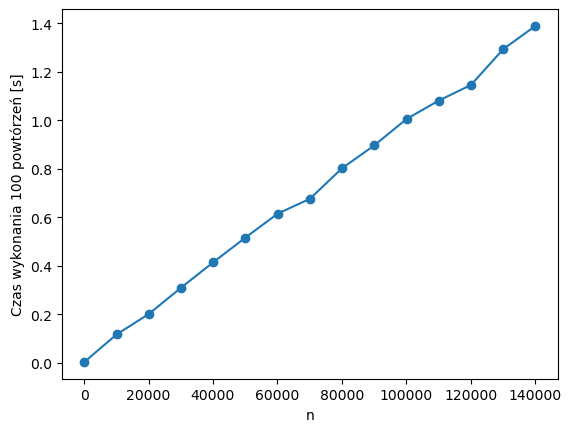

In [41]:
ns = np.arange(100, 150000, 10000)
times = [];
reps = 100;

for n in ns:
    x = np.random.normal(size=n)
    times.append(timeit("suma(x)", globals=globals(), number=reps))

plt.plot(ns, times, marker="o")
plt.xlabel("n");
plt.ylabel(f"Czas wykonania {reps} powtórzeń [s]");

In [ ]:
def suma(tab):
    suma=0; # 1 op. (przypisanie)
    for x in tab: # zakładamy, że 1 przypisanie na każdy obrót pętli
        suma += x # 1 sumowanie na każdy obrót pętli

    return suma; # zał. że 1 operacja

In [ ]:
def suma(tab):
    suma=0;
    for x in tab:
        suma += x # op. dom. 

    return suma;

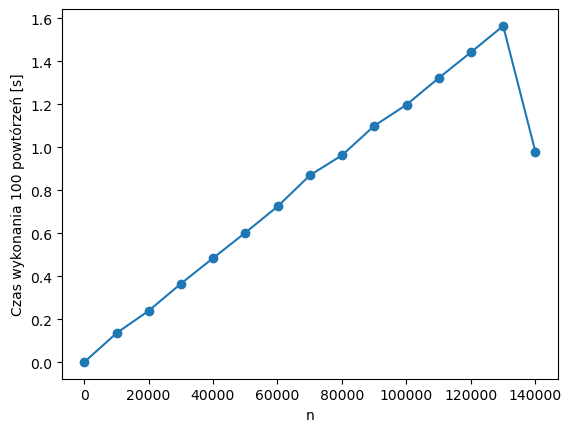

In [42]:
ns = np.arange(100, 150000, 10000)
times = [];
reps = 100;

for n in ns:
    x = np.random.normal(size=n)
    times.append(timeit("sum(x)", globals=globals(), number=reps))

plt.plot(ns, times, marker="o")
plt.xlabel("n");
plt.ylabel(f"Czas wykonania {reps} powtórzeń [s]");

In [43]:
np.sum([1,2,3])

np.int64(6)

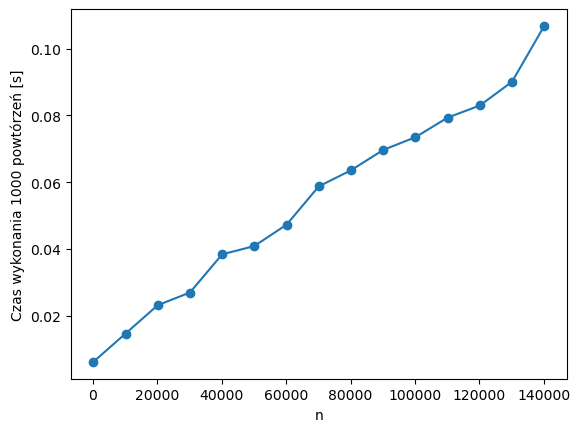

In [45]:
ns = np.arange(100, 150000, 10000)
times = [];
reps = 1000;

for n in ns:
    x = np.random.normal(size=n)
    times.append(timeit("np.sum(x)", globals=globals(), number=reps))

plt.plot(ns, times, marker="o")
plt.xlabel("n");
plt.ylabel(f"Czas wykonania {reps} powtórzeń [s]");

In [46]:
def silnia_iter(n):
    silnia = 1;
    for i in range(2, n+1):
        silnia *= i;
    return silnia;

In [47]:
silnia_iter(3)

6

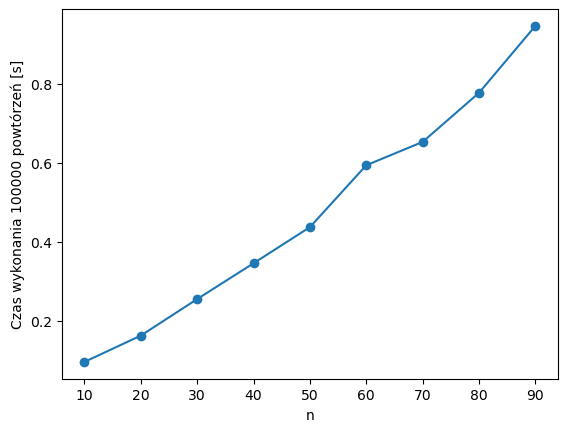

In [48]:
ns = np.arange(10, 100, 10)
times = [];
reps = 100000;

for n in ns:
    times.append(timeit("silnia_iter(n)", globals=globals(), number=reps))

plt.plot(ns, times, marker="o")
plt.xlabel("n");
plt.ylabel(f"Czas wykonania {reps} powtórzeń [s]");

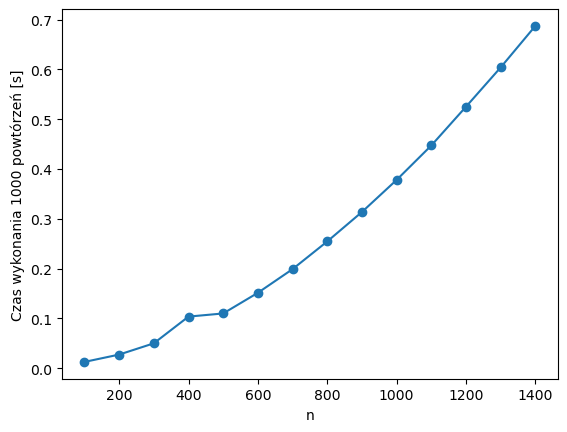

In [50]:
ns = np.arange(100, 1500, 100)
times = [];
reps = 1000;

for n in ns:
    times.append(timeit("silnia_iter(n)", globals=globals(), number=reps))

plt.plot(ns, times, marker="o")
plt.xlabel("n");
plt.ylabel(f"Czas wykonania {reps} powtórzeń [s]");